In [9]:
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv("../dataset/updated_pollution_dataset.csv")

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Air Quality"] = le.fit_transform(df["Air Quality"])

In [12]:
df["Air Quality"] = df["Air Quality"].apply(lambda x: 1 if x > 1 else 0)

In [13]:
X = df.drop("Air Quality", axis=1)
y = df["Air Quality"]

In [23]:
class LogisticRegressionScratch:
    def __init__(self,learning_rate = 0.001, iterations = 1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
    def sigmoid(self,z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    def compute_cost(self,y,y_pred):
        m = len(y)
        epsilon = 1e-9
        y_pred = np.clip(y_pred,epsilon, 1 - epsilon)
        cost = -(1/m)*np.sum(y*np.log(y_pred)+(1-y)*np.log(1-y_pred))
        return cost
    def fit(self,X,y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for i in range(self.iterations):
            linear_output = np.dot(X,self.weights)+self.bias
            y_pred = self.sigmoid(linear_output)
            cost = self.compute_cost(y,y_pred)
            self.cost_history.append(cost)
            dw = (1/n_samples)*np.dot(X.T,(y_pred-y)) # uses tranpose 
            db = (1/n_samples)*np.sum(y_pred-y)
            w_new = self.weights - self.learning_rate*dw
            self.weights = w_new
            b_new = self.bias - self.learning_rate*db
            self.bias = b_new
            if i % 500 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")
    def predict_proba(self,X):
        linear_output = np.dot(X,self.weights)+self.bias
        return self.sigmoid(linear_output)
    def predict(self,X):
        probabilities = self.predict_proba(X)
        return np.array([1 if p>=0.5 else 0 for p in probabilities])

In [24]:
X.shape, y.shape

((5000, 9), (5000,))

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
model = LogisticRegressionScratch(learning_rate=0.01,iterations = 2000)
model.fit(X_train,y_train)

Iteration 0: Cost = 0.6931


Iteration 500: Cost = 0.5393
Iteration 1000: Cost = 0.5147
Iteration 1500: Cost = 0.5021


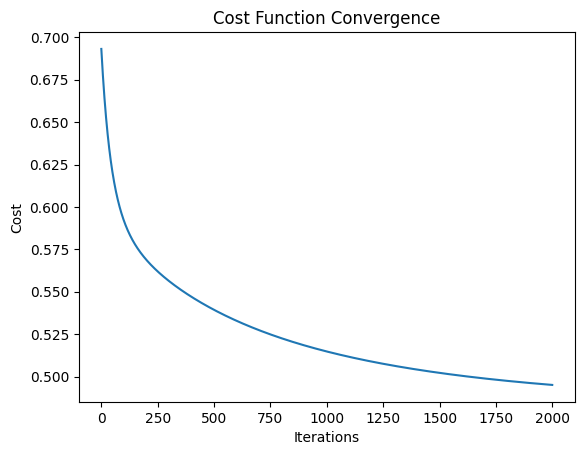

In [31]:
import matplotlib.pyplot as plt
plt.plot(model.cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.show()

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)

In [34]:
accuracy

0.827